# EDA 05.05 — Extremes, Exploratory Peaks, and Feature Review

All calculations use `master_dataset_clean.parquet`. The source dataset is not modified.

In [1]:
# Import libraries
from pathlib import Path
import sys
from IPython.display import Image, display

In [2]:
# define the root directory of the project
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'eda.yaml'
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/Codigo/ontario-electricity-peak-risk/configs/eda.yaml')

In [3]:
# Import module to manage the EDA process
from src.ontario_peak_risk.eda.common import (
    load_eda_config,
    prepare_output_directories,
    load_clean_dataset,
)

In [4]:
# Config EDA process and Load the dataset
CONFIG, _ = load_eda_config(CONFIG_PATH)
REPORTS_DIR, FIGURES_DIR, DOCS_DIR = prepare_output_directories(CONFIG, PROJECT_ROOT)
dataset = load_clean_dataset(CONFIG, PROJECT_ROOT)
TARGET = CONFIG['columns']['target']

dataset.shape

(262944, 66)

In [5]:
# Import the function to run the extremes and peaks analysis
from src.ontario_peak_risk.eda.extremes_peaks import run_extremes_peaks

In [6]:
# Generate the extremes and peaks analysis of the dataset and save the results in the output directories
results = run_extremes_peaks(
    dataset,
    TARGET,
    CONFIG['analysis']['exploratory_peak_percentile'],
    CONFIG['analysis']['top_n_extreme_hours'],
    CONFIG['analysis']['top_n_extreme_days'],
    REPORTS_DIR,
    FIGURES_DIR,
    DOCS_DIR,
)

print("Extremes and peaks analysis completed.")

Extremes and peaks analysis completed.


In [7]:
# Display results of the extremes and peaks analysis
results['peaks_by_fsa']

,fsa,rows,exploratory_peak_hours,exploratory_peak_pct,peak_mean_consumption_kwh
0,L4T,43824,1096,2.500913,18955.392336
1,M5R,43824,1096,2.500913,12103.784124
2,M5S,43824,1096,2.500913,6225.728741
3,M6G,43824,1096,2.500913,18451.305383
4,M9R,43824,1096,2.500913,9827.718248
5,M9W,43824,1096,2.500913,21700.190146


In [8]:
# Display the highest-demand hourly observations
results["extreme_hours"]

,fsa,timestamp,total_consumption_kwh,Temp (°C),Rel Hum (%),season,hour,weekday_name,is_weekend,is_public_holiday,assigned_station_name
0,M9W,2025-06-24 14:00:00,33712.2,34.0,47.0,Summer,14,Tuesday,0,0,TORONTO INTL A
1,M9W,2025-06-24 15:00:00,33617.2,34.8,43.0,Summer,15,Tuesday,0,0,TORONTO INTL A
2,M9W,2025-06-24 13:00:00,33566.5,34.7,44.0,Summer,13,Tuesday,0,0,TORONTO INTL A
3,M9W,2025-06-23 16:00:00,33203.0,35.8,39.0,Summer,16,Monday,0,0,TORONTO INTL A
4,M9W,2025-06-23 15:00:00,33183.9,35.7,37.0,Summer,15,Monday,0,0,TORONTO INTL A
5,M9W,2025-06-24 12:00:00,32941.0,34.4,47.0,Summer,12,Tuesday,0,0,TORONTO INTL A
6,M9W,2025-06-23 17:00:00,32709.0,35.2,36.0,Summer,17,Monday,0,0,TORONTO INTL A
7,M9W,2025-06-23 14:00:00,32661.3,35.2,42.0,Summer,14,Monday,0,0,TORONTO INTL A
8,M9W,2025-06-24 16:00:00,32556.8,34.3,44.0,Summer,16,Tuesday,0,0,TORONTO INTL A
9,M9W,2025-06-23 18:00:00,32295.9,33.6,49.0,Summer,18,Monday,0,0,TORONTO INTL A


In [9]:
# Display the highest-demand FSA-days
results["extreme_days"]

,fsa,date_analysis,daily_total_kwh,daily_mean_kwh,maximum_hourly_kwh,mean_temperature_c
0,M9W,2025-06-24,652911.7,27204.654167,33712.2,29.950000
1,M9W,2025-06-23,640718.1,26696.587500,33203.0,29.945833
2,M9W,2025-08-11,577356.1,24056.504167,32007.9,27.841667
3,M9W,2025-07-29,576470.2,24019.591667,31112.8,26.737500
4,M9W,2025-06-25,573102.4,23879.266667,30101.1,26.283333
5,M9W,2025-07-28,571828.0,23826.166667,31479.3,27.425000
6,M9W,2025-07-06,568133.1,23672.212500,30855.1,29.087500
7,M9W,2025-08-12,568041.0,23668.375000,31481.4,27.012500
8,M9W,2025-06-22,565658.0,23569.083333,31248.5,29.858333
9,M9W,2025-07-12,561707.7,23404.487500,30235.6,28.108333


In [10]:
# Display exploratory Peak thresholds by FSA and season
results["peak_thresholds"]

,fsa,season,exploratory_peak_threshold_kwh
0,L4T,Fall,16207.3000
1,L4T,Spring,14568.3225
2,L4T,Summer,23822.3750
3,L4T,Winter,15546.2225
4,M5R,Fall,9800.8225
5,M5R,Spring,10006.9950
6,M5R,Summer,13102.3525
7,M5R,Winter,12488.2125
8,M5S,Fall,5295.3075
9,M5S,Spring,5386.4050


In [11]:
# Display exploratory Peak statistics by FSA
results["peaks_by_fsa"]

,fsa,rows,exploratory_peak_hours,exploratory_peak_pct,peak_mean_consumption_kwh
0,L4T,43824,1096,2.500913,18955.392336
1,M5R,43824,1096,2.500913,12103.784124
2,M5S,43824,1096,2.500913,6225.728741
3,M6G,43824,1096,2.500913,18451.305383
4,M9R,43824,1096,2.500913,9827.718248
5,M9W,43824,1096,2.500913,21700.190146


In [12]:
# Display the overall exploratory Peak context summary
results["peak_summary"]

,peak_records,mean_peak_consumption_kwh,median_peak_consumption_kwh,maximum_peak_consumption_kwh,mean_peak_temperature_c,mean_peak_relative_humidity_pct,most_common_peak_hour,most_common_peak_month,most_common_peak_weekday,most_common_peak_season,most_common_peak_fsa
0,6576,14544.01983,14892.1,33712.2,12.355809,59.861162,18,March,Sunday,Spring,L4T


In [13]:
# Display exploratory Peak occurrence by month
results["peaks_by_month"]

,month,month_name,peak_hours
0,1,January,785
1,2,February,379
2,3,March,1033
3,4,April,48
4,5,May,575
5,6,June,398
6,7,July,790
7,8,August,468
8,9,September,993
9,10,October,141


In [14]:
# Display exploratory Peak occurrence by weekday
results["peaks_by_weekday"]

,weekday,weekday_name,peak_hours
0,0,Monday,1023
1,1,Tuesday,1112
2,2,Wednesday,920
3,3,Thursday,508
4,4,Friday,426
5,5,Saturday,977
6,6,Sunday,1610


In [15]:
# Display exploratory Peak occurrence by season
results["peaks_by_season"]

,season,peak_hours
0,Fall,1638
1,Spring,1656
2,Summer,1656
3,Winter,1626


In [16]:
# Display temperature-extreme demand comparison
results["temperature_extremes"]

,fsa,temperature_extreme,count,mean_consumption_kwh,median_consumption_kwh,maximum_consumption_kwh,mean_temperature_c
0,L4T,coldest_1_percent,576,12095.578993,11606.35,17348.1,-14.445139
1,L4T,hottest_1_percent,543,23175.311234,23573.60,27796.6,30.942357
2,L4T,non_extreme,42699,11464.264526,11123.00,25855.0,9.990461
3,M5R,coldest_1_percent,326,10345.556442,10198.20,14039.3,-14.290184
4,M5R,hottest_1_percent,334,13139.100299,13167.40,16999.0,30.791317
5,M5R,non_extreme,43123,7599.309306,7423.40,15302.1,10.523287
6,M5S,coldest_1_percent,326,5509.378528,5398.60,7438.5,-14.290184
7,M5S,hottest_1_percent,334,6274.352096,6294.90,7533.8,30.791317
8,M5S,non_extreme,43123,4081.531032,4025.30,7622.4,10.523287
9,M6G,coldest_1_percent,326,14255.247546,14069.75,20236.4,-14.290184


In [17]:
# Display the feature review identified in the analysis
results["feature_review"]

,column,dtype,missing_pct,unique_count,preliminary_recommendation,reason
0,fsa,category,0.000000,6,retain_candidate,Potentially useful predictor; final selection ...
1,timestamp,datetime64[ns],0.000000,43824,retain_for_traceability_not_directly_as_numeri...,Identifier or temporal audit field.
2,total_consumption_kwh,float64,0.000000,157393,target_keep,Primary forecasting target.
3,reported_premise_count,Int64,0.000000,1269,retain_candidate,Potentially useful predictor; final selection ...
4,source_segment_count,Int8,0.000000,6,retain_candidate,Potentially useful predictor; final selection ...
...,...,...,...,...,...,...
61,Visibility (km),float64,50.007986,30,retain_for_eda_then_review_model_specific_hand...,Substantial missingness but potentially meanin...
62,Stn Press (kPa),float64,0.053624,664,retain_candidate,Potentially useful predictor; final selection ...
63,Hmdx,float64,82.395491,22,review_for_exclusion_or_special_handling,Very high missingness; usefulness must be demo...
64,Wind Chill,float64,89.980376,34,review_for_exclusion_or_special_handling,Very high missingness; usefulness must be demo...


In [18]:
# Display variables requiring additional review before modeling
results["feature_review"].query(
    "preliminary_recommendation != 'retain_candidate'"
)

,column,dtype,missing_pct,unique_count,preliminary_recommendation,reason
1,timestamp,datetime64[ns],0.000000,43824,retain_for_traceability_not_directly_as_numeri...,Identifier or temporal audit field.
2,total_consumption_kwh,float64,0.000000,157393,target_keep,Primary forecasting target.
7,timestamp_utc,"datetime64[ns, UTC]",0.000000,43824,retain_for_traceability_not_directly_as_numeri...,Identifier or temporal audit field.
8,timestamp_toronto,"datetime64[ns, UTC]",0.000000,43824,retain_for_traceability_not_directly_as_numeri...,Identifier or temporal audit field.
9,date,datetime64[ns],0.000000,1826,retain_for_traceability_not_directly_as_numeri...,Identifier or temporal audit field.
13,month_name,category,0.000000,12,review_encoding_or_redundancy,Categorical/descriptive field may duplicate en...
20,weekday_name,category,0.000000,7,review_encoding_or_redundancy,Categorical/descriptive field may duplicate en...
33,holiday_name,category,0.000000,14,review_encoding_or_redundancy,Categorical/descriptive field may duplicate en...
51,assigned_climate_id,Int64,0.000000,2,retain_for_traceability_not_directly_as_numeri...,Identifier or temporal audit field.
52,assigned_station_name,category,0.000000,2,retain_for_traceability_not_directly_as_numeri...,Identifier or temporal audit field.


In [19]:
# View the peak context identified in the analysis
results["peak_context"].head(30)

,fsa,season,hour,assigned_station_name,peak_hours,mean_peak_consumption_kwh,mean_temperature_c,mean_relative_humidity_pct
0,L4T,Fall,0,TORONTO INTL A,1,16391.700000,24.200000,79.000000
1,L4T,Fall,8,TORONTO INTL A,1,16781.400000,25.200000,78.000000
2,L4T,Fall,9,TORONTO INTL A,3,18082.633333,27.033333,65.333333
3,L4T,Fall,10,TORONTO INTL A,5,18972.320000,27.440000,65.400000
4,L4T,Fall,11,TORONTO INTL A,10,18896.370000,26.730000,63.300000
5,L4T,Fall,12,TORONTO INTL A,18,18396.544444,26.522222,60.055556
6,L4T,Fall,13,TORONTO INTL A,23,18398.808696,26.639130,57.652174
7,L4T,Fall,14,TORONTO INTL A,28,18396.857143,26.257143,57.785714
8,L4T,Fall,15,TORONTO INTL A,34,18362.238235,26.294118,55.235294
9,L4T,Fall,16,TORONTO INTL A,35,18331.231429,25.920000,54.257143


In [20]:
# View the temperature extremes identified in the analysis
results["temperature_extremes"]

,fsa,temperature_extreme,count,mean_consumption_kwh,median_consumption_kwh,maximum_consumption_kwh,mean_temperature_c
0,L4T,coldest_1_percent,576,12095.578993,11606.35,17348.1,-14.445139
1,L4T,hottest_1_percent,543,23175.311234,23573.60,27796.6,30.942357
2,L4T,non_extreme,42699,11464.264526,11123.00,25855.0,9.990461
3,M5R,coldest_1_percent,326,10345.556442,10198.20,14039.3,-14.290184
4,M5R,hottest_1_percent,334,13139.100299,13167.40,16999.0,30.791317
5,M5R,non_extreme,43123,7599.309306,7423.40,15302.1,10.523287
6,M5S,coldest_1_percent,326,5509.378528,5398.60,7438.5,-14.290184
7,M5S,hottest_1_percent,334,6274.352096,6294.90,7533.8,30.791317
8,M5S,non_extreme,43123,4081.531032,4025.30,7622.4,10.523287
9,M6G,coldest_1_percent,326,14255.247546,14069.75,20236.4,-14.290184


In [21]:
# View the feature review identified in the analysis
results["feature_review"]

,column,dtype,missing_pct,unique_count,preliminary_recommendation,reason
0,fsa,category,0.000000,6,retain_candidate,Potentially useful predictor; final selection ...
1,timestamp,datetime64[ns],0.000000,43824,retain_for_traceability_not_directly_as_numeri...,Identifier or temporal audit field.
2,total_consumption_kwh,float64,0.000000,157393,target_keep,Primary forecasting target.
3,reported_premise_count,Int64,0.000000,1269,retain_candidate,Potentially useful predictor; final selection ...
4,source_segment_count,Int8,0.000000,6,retain_candidate,Potentially useful predictor; final selection ...
...,...,...,...,...,...,...
61,Visibility (km),float64,50.007986,30,retain_for_eda_then_review_model_specific_hand...,Substantial missingness but potentially meanin...
62,Stn Press (kPa),float64,0.053624,664,retain_candidate,Potentially useful predictor; final selection ...
63,Hmdx,float64,82.395491,22,review_for_exclusion_or_special_handling,Very high missingness; usefulness must be demo...
64,Wind Chill,float64,89.980376,34,review_for_exclusion_or_special_handling,Very high missingness; usefulness must be demo...


In [22]:
# Display exploratory Peak Rate by hour
results["peak_rate_by_hour"]

,hour,total_observations,peak_observations,peak_rate_pct
0,0,10956,4,0.036510
1,1,10956,0,0.000000
2,2,10956,0,0.000000
3,3,10956,0,0.000000
4,4,10956,0,0.000000
5,5,10956,0,0.000000
6,6,10956,0,0.000000
7,7,10956,1,0.009127
8,8,10956,15,0.136911
9,9,10956,33,0.301205


In [23]:
# Display exploratory Peak Rate by weekday
results["peak_rate_by_weekday"]

,weekday,weekday_name,total_observations,peak_observations,peak_rate_pct
0,0,Monday,37584,1023,2.721903
1,1,Tuesday,37584,1112,2.958706
2,2,Wednesday,37584,920,2.447850
3,3,Thursday,37440,508,1.356838
4,4,Friday,37584,426,1.133461
5,5,Saturday,37584,977,2.599510
6,6,Sunday,37584,1610,4.283738


In [24]:
# Display exploratory Peak Rate by month
results["peak_rate_by_month"]

,month,month_name,total_observations,peak_observations,peak_rate_pct
0,1,January,22320,785,3.517025
1,2,February,20304,379,1.866627
2,3,March,22320,1033,4.628136
3,4,April,21600,48,0.222222
4,5,May,22320,575,2.576165
5,6,June,21600,398,1.842593
6,7,July,22320,790,3.539427
7,8,August,22320,468,2.096774
8,9,September,21600,993,4.597222
9,10,October,22320,141,0.631720


In [25]:
# Display annual evolution of exploratory Peak Rate
results["peak_rate_by_year"]

,year,total_observations,peak_observations,peak_rate_pct
0,2021,52560,631,1.200533
1,2022,52560,1034,1.967275
2,2023,52560,1137,2.163242
3,2024,52704,1159,2.199074
4,2025,52560,2615,4.975266


In [26]:
# Display Peak Episode overview
results["peak_episode_summary"]

,episode_count,mean_episode_duration_hours,median_episode_duration_hours,maximum_episode_duration_hours,single_hour_episodes,multi_hour_episodes
0,1542,4.264591,3.0,17,243,1299


In [27]:
# Display Peak Episode duration distribution
results["peak_episode_duration"]

,duration_hours,episode_count,episode_pct
0,1,243,15.758755
1,2,313,20.298314
2,3,242,15.693904
3,4,220,14.267185
4,5,153,9.922179
5,6,82,5.317769
6,7,54,3.501946
7,8,51,3.307393
8,9,47,3.047990
9,10,35,2.269780


In [28]:
# Display the longest exploratory Peak Episodes
(
    results["peak_episodes"]
    .sort_values(
        "duration_hours",
        ascending=False,
    )
    .head(20)
)

,fsa,episode_id,episode_start,episode_end,duration_hours,maximum_consumption_kwh,mean_consumption_kwh,mean_temperature_c,season
840,M6G,81,2023-09-05 08:00:00,2023-09-06 00:00:00,17,23652.4,20106.835294,27.511765,Fall
1341,M9W,46,2023-09-06 07:00:00,2023-09-06 22:00:00,16,29740.5,25623.631250,27.643750,Fall
1121,M9R,96,2023-09-06 08:00:00,2023-09-06 23:00:00,16,13883.4,11484.768750,27.587500,Fall
103,L4T,104,2023-09-05 09:00:00,2023-09-06 00:00:00,16,25114.0,22315.181250,28.900000,Fall
1340,M9W,45,2023-09-05 08:00:00,2023-09-05 23:00:00,16,29812.2,26052.237500,29.012500,Fall
352,M5R,144,2023-09-05 08:00:00,2023-09-05 23:00:00,16,14484.0,12778.856250,27.725000,Fall
1119,M9R,94,2023-09-04 09:00:00,2023-09-05 00:00:00,16,14852.6,12285.475000,28.843750,Fall
69,L4T,70,2022-05-31 08:00:00,2022-05-31 23:00:00,16,21973.1,19353.362500,29.381250,Spring
1120,M9R,95,2023-09-05 08:00:00,2023-09-05 23:00:00,16,13803.9,11599.656250,29.012500,Fall
841,M6G,82,2023-09-06 08:00:00,2023-09-06 23:00:00,16,23616.3,20196.612500,26.743750,Fall


## Summary
Review the generated CSV tables, figures, and Markdown section report.

Review: 
- Report under `docs/eda/05_05_Extremes_Peaks_and_Feature_Review.md`.
- CSV reports under `reports/eda/`.

Generated figures: 12

05_05_exploratory_peaks_by_hour.png


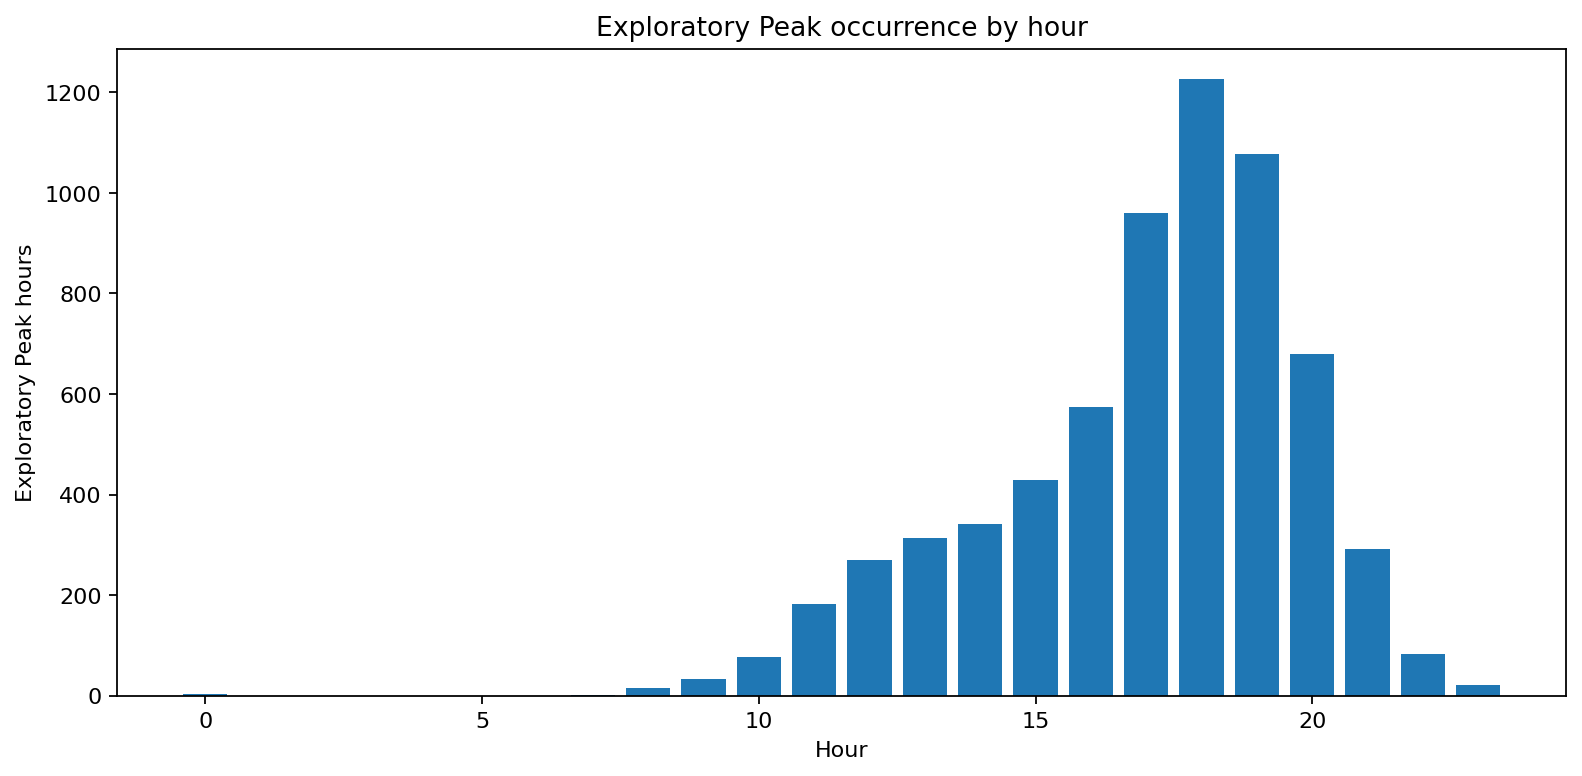


05_05_extreme_days.png


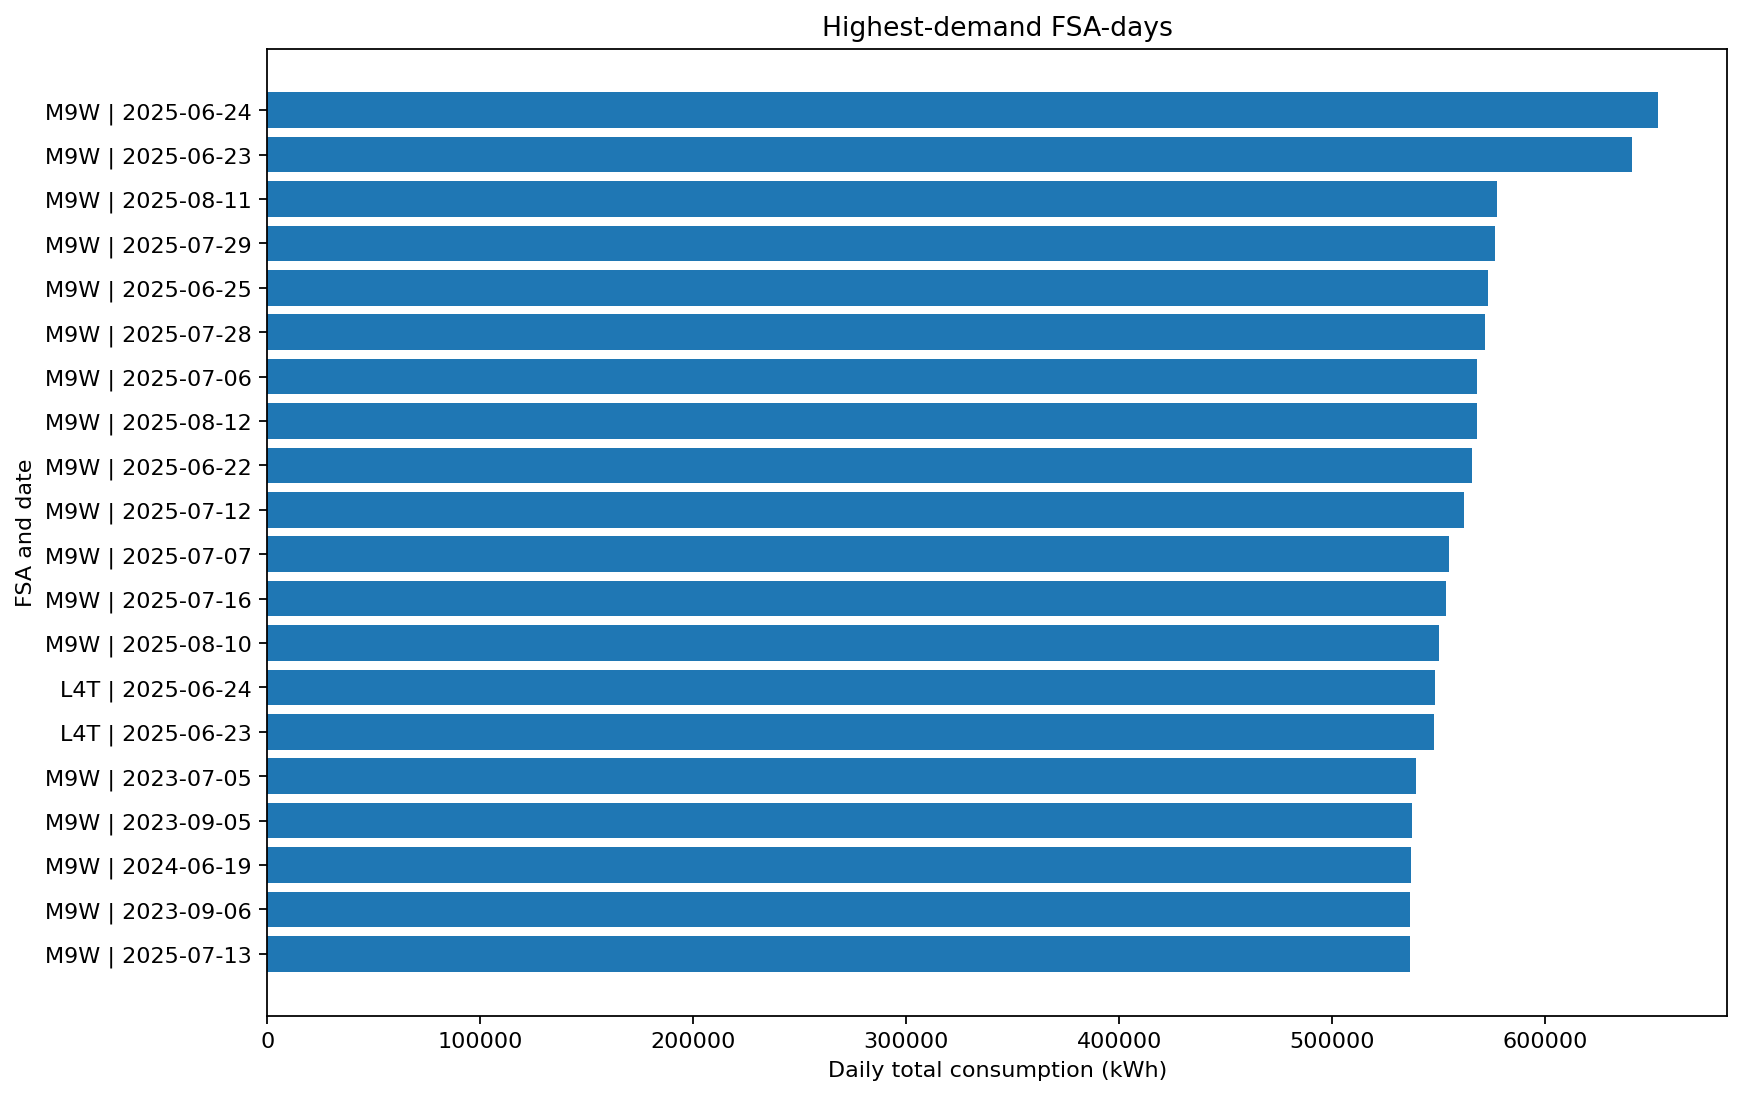


05_05_peak_episode_duration.png


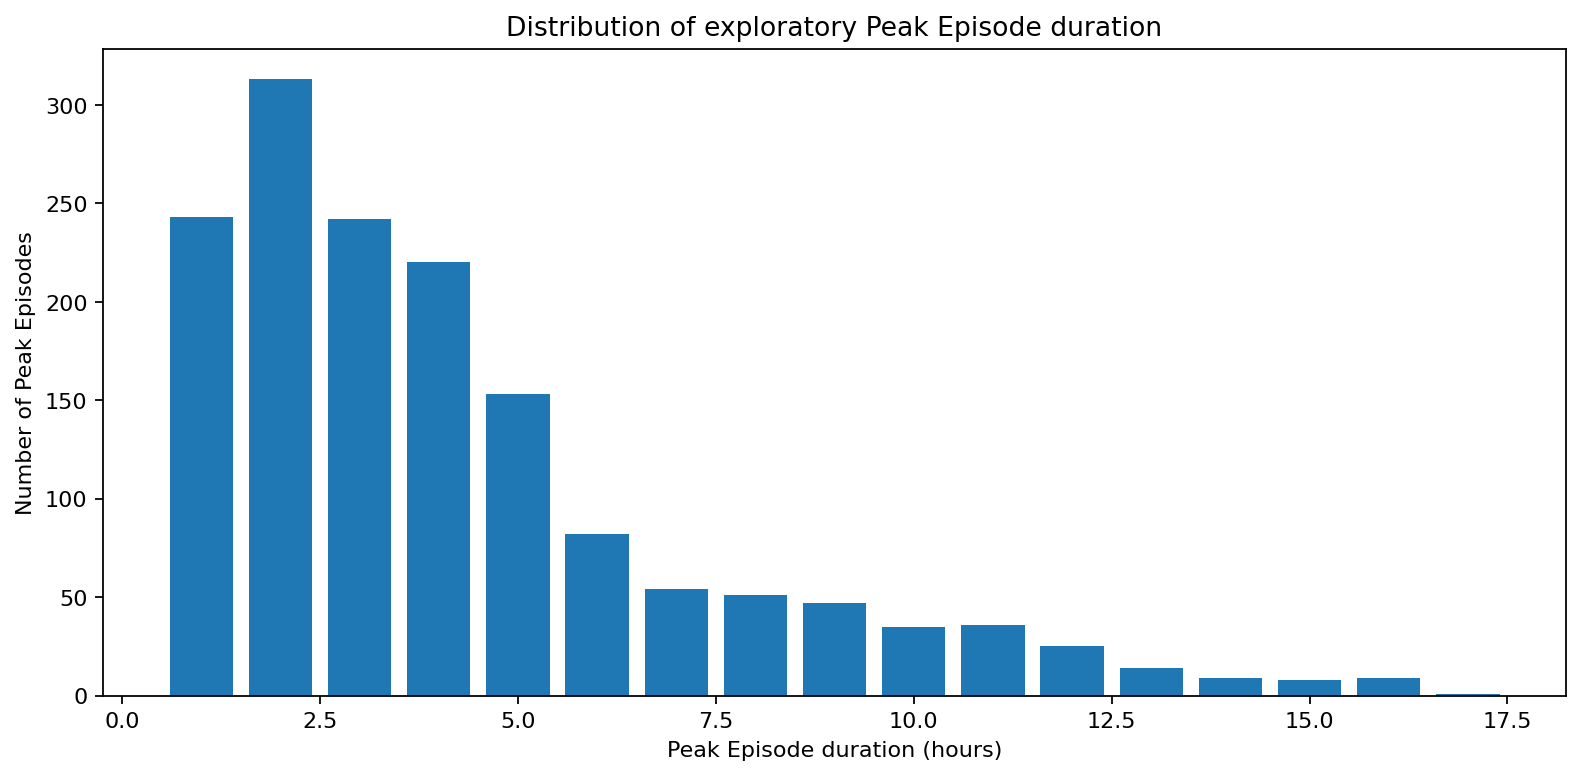


05_05_peak_rate_by_hour.png


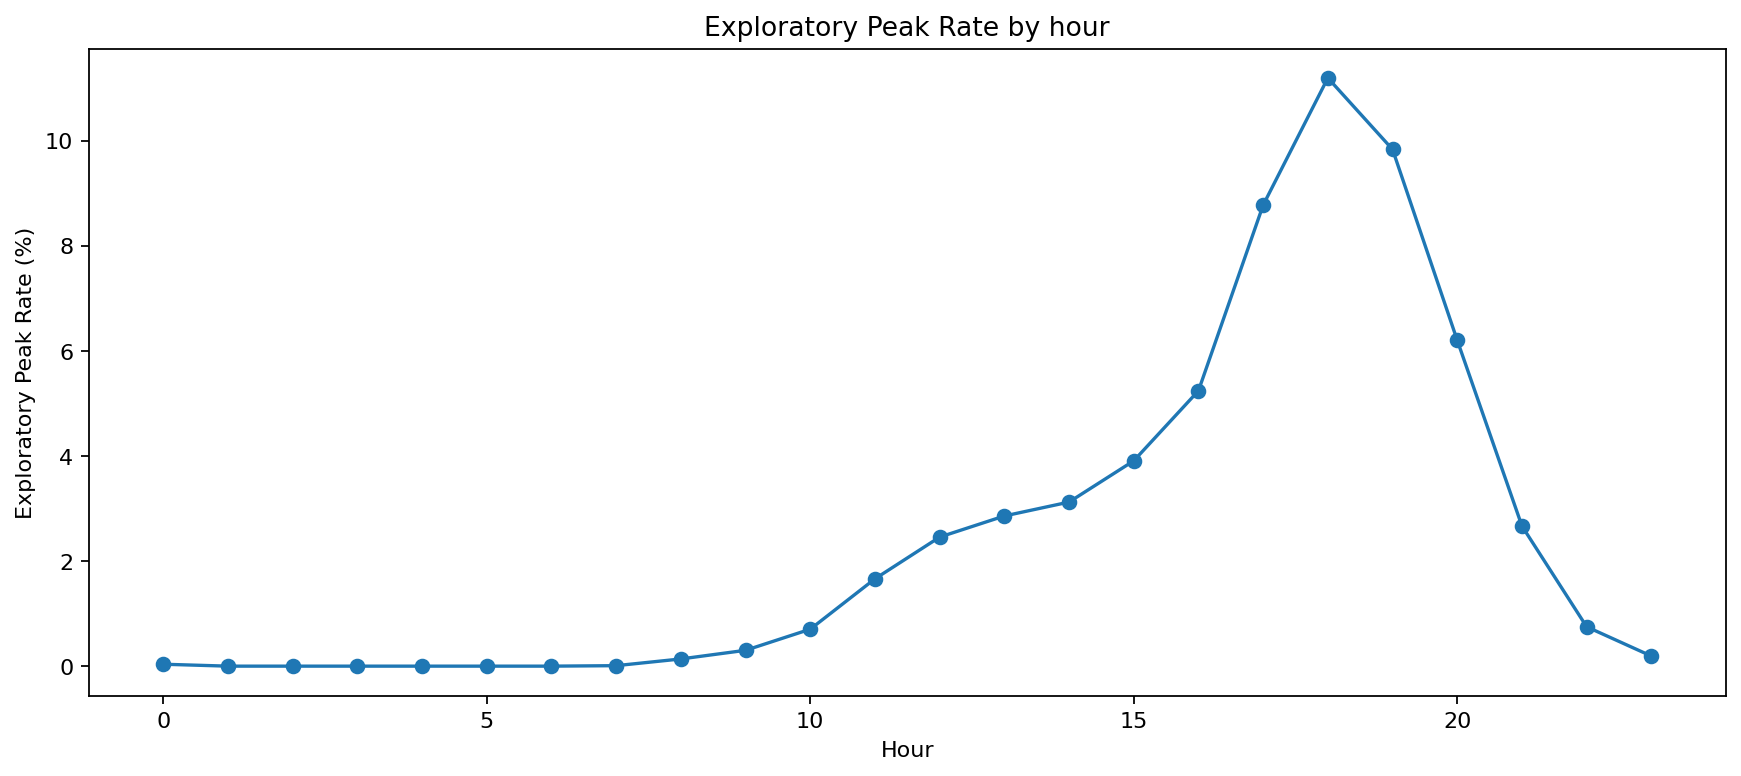


05_05_peak_rate_by_month.png


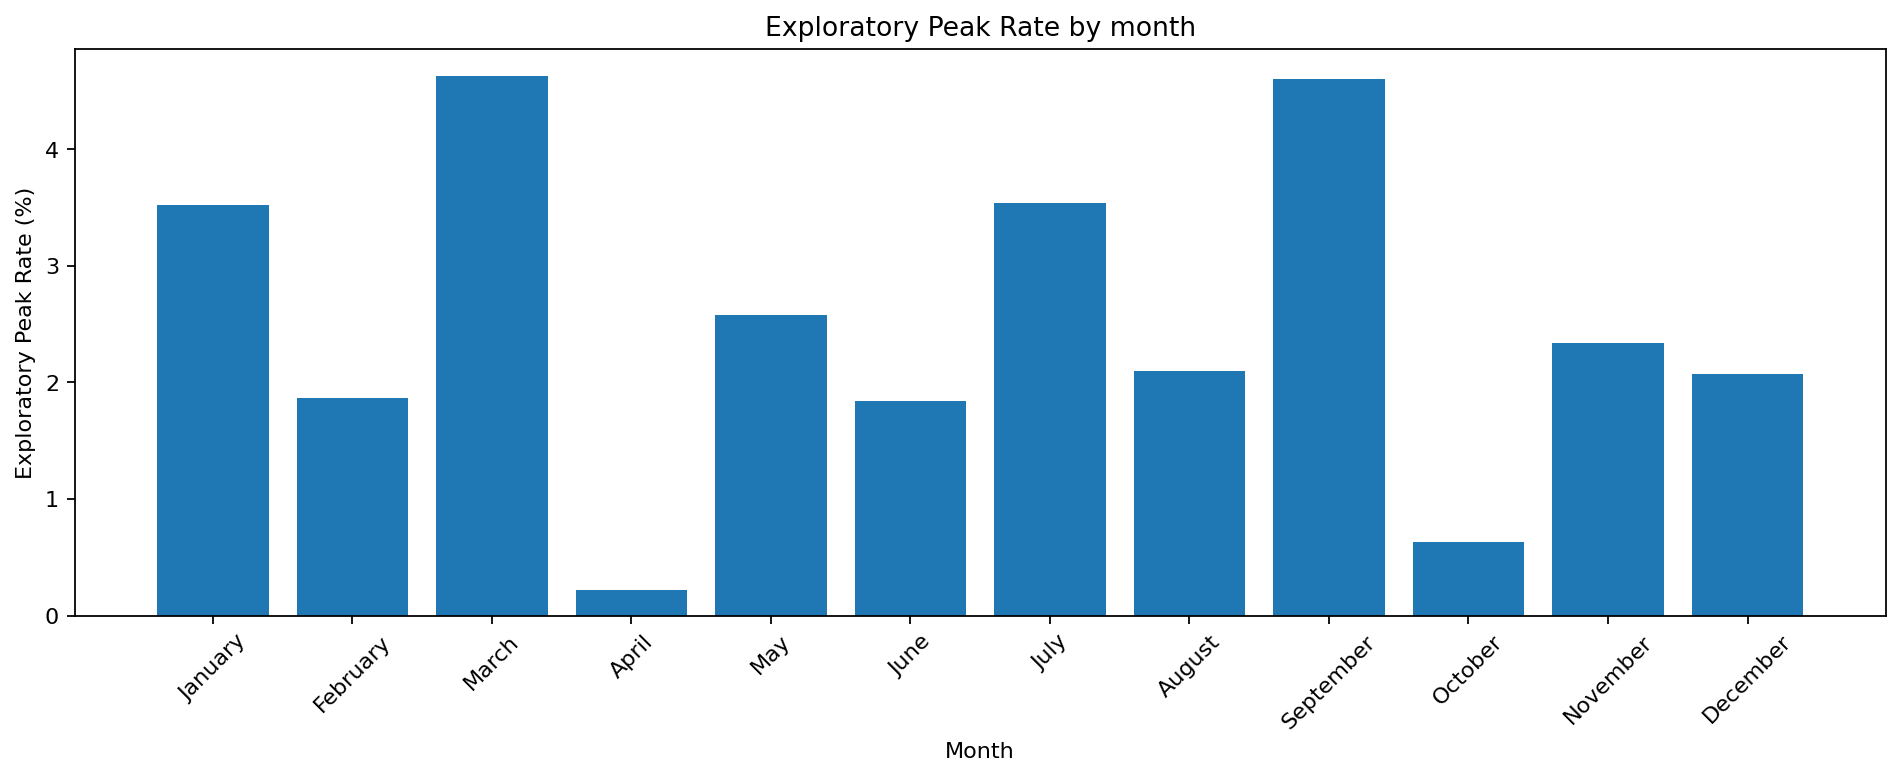


05_05_peak_rate_by_weekday.png


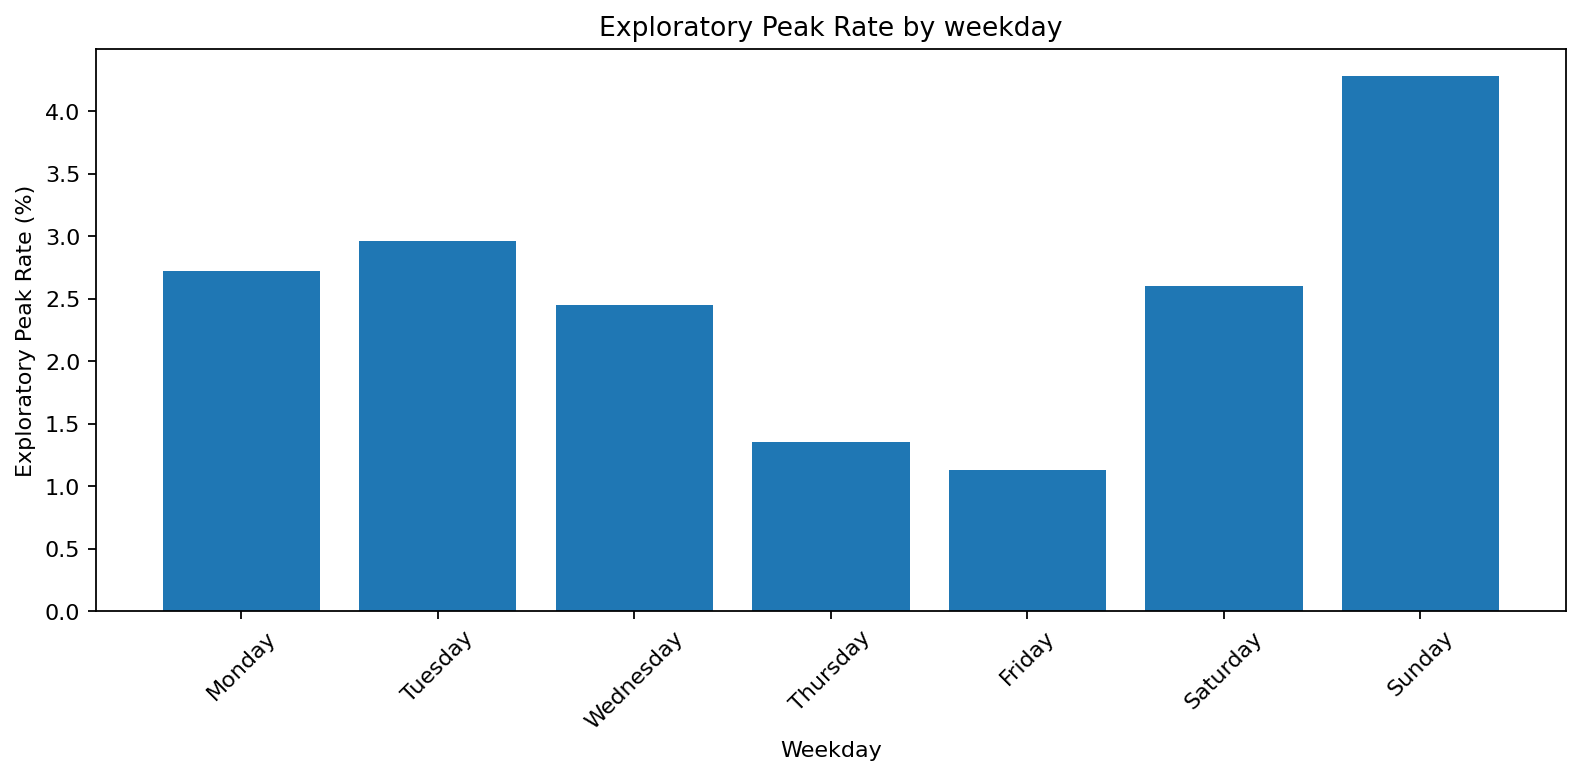


05_05_peak_rate_by_year.png


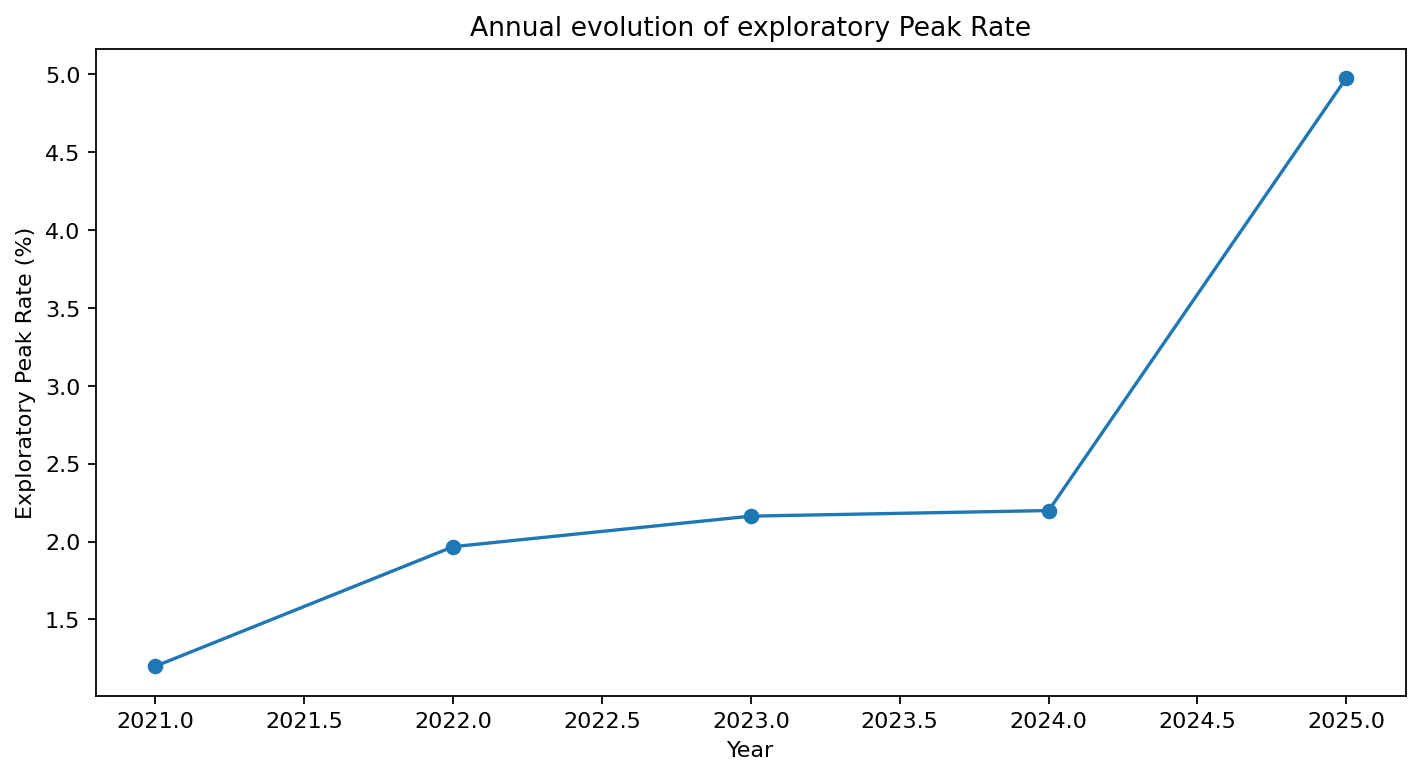


05_05_peak_thresholds_by_fsa_season.png


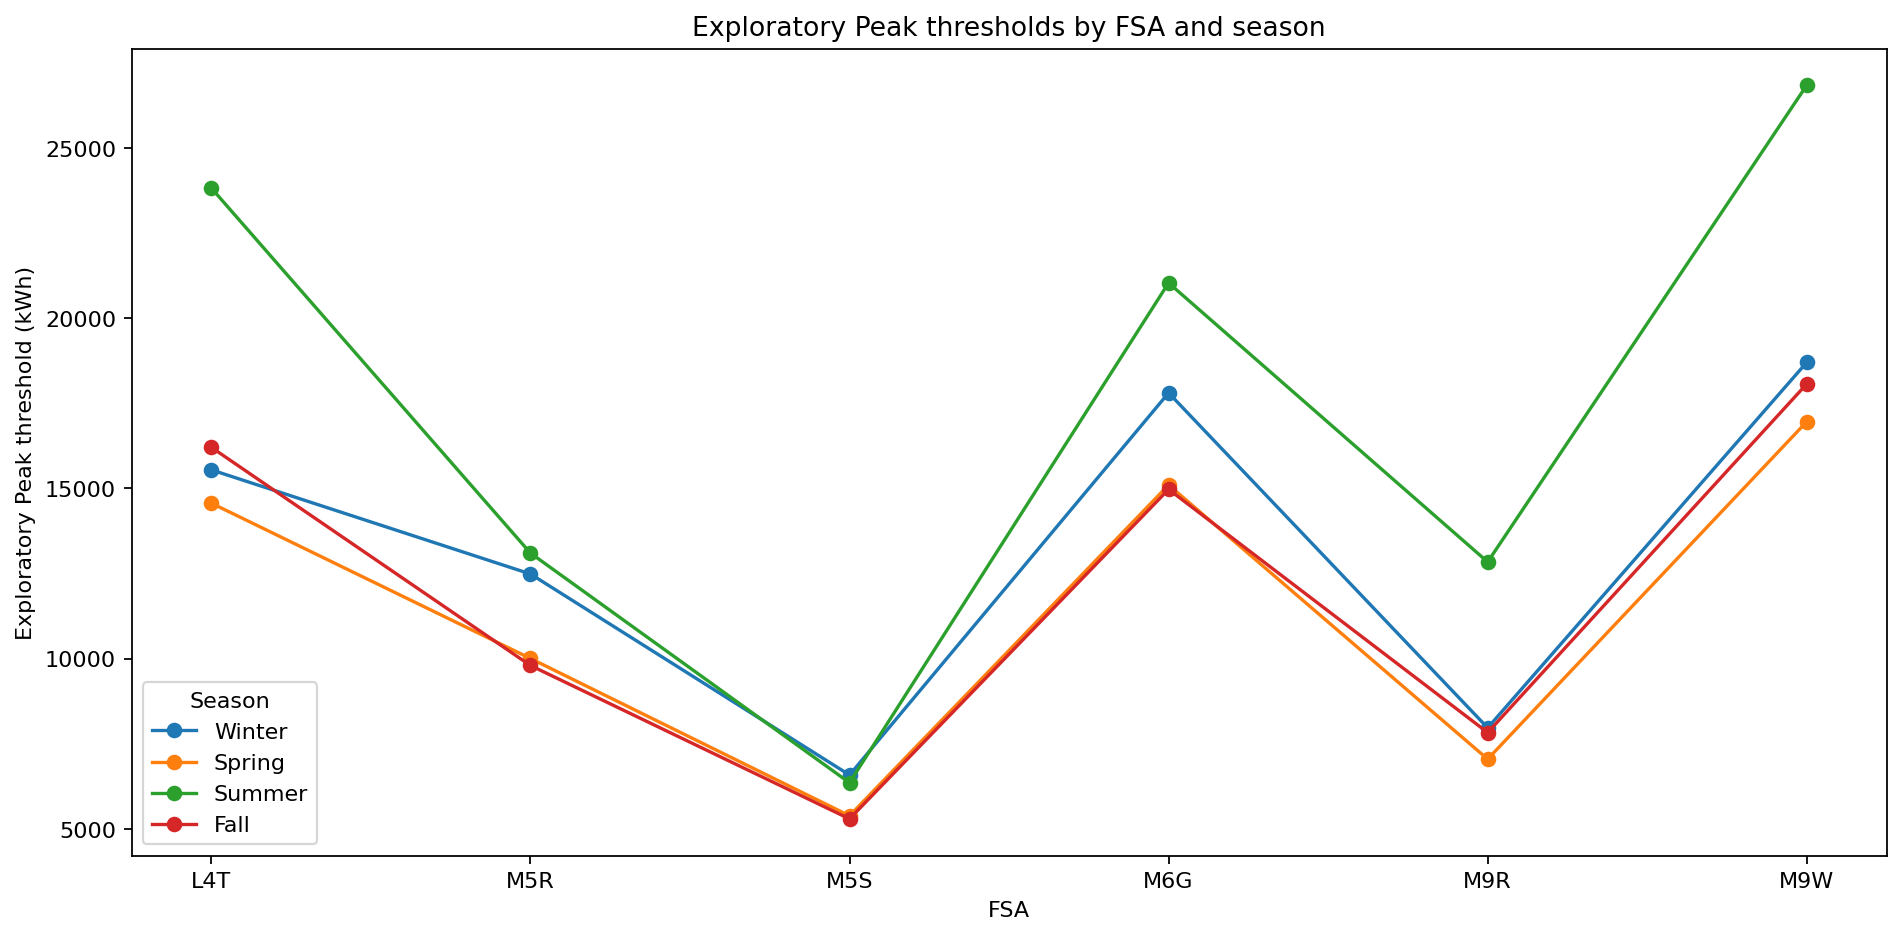


05_05_peaks_by_hour_and_season.png


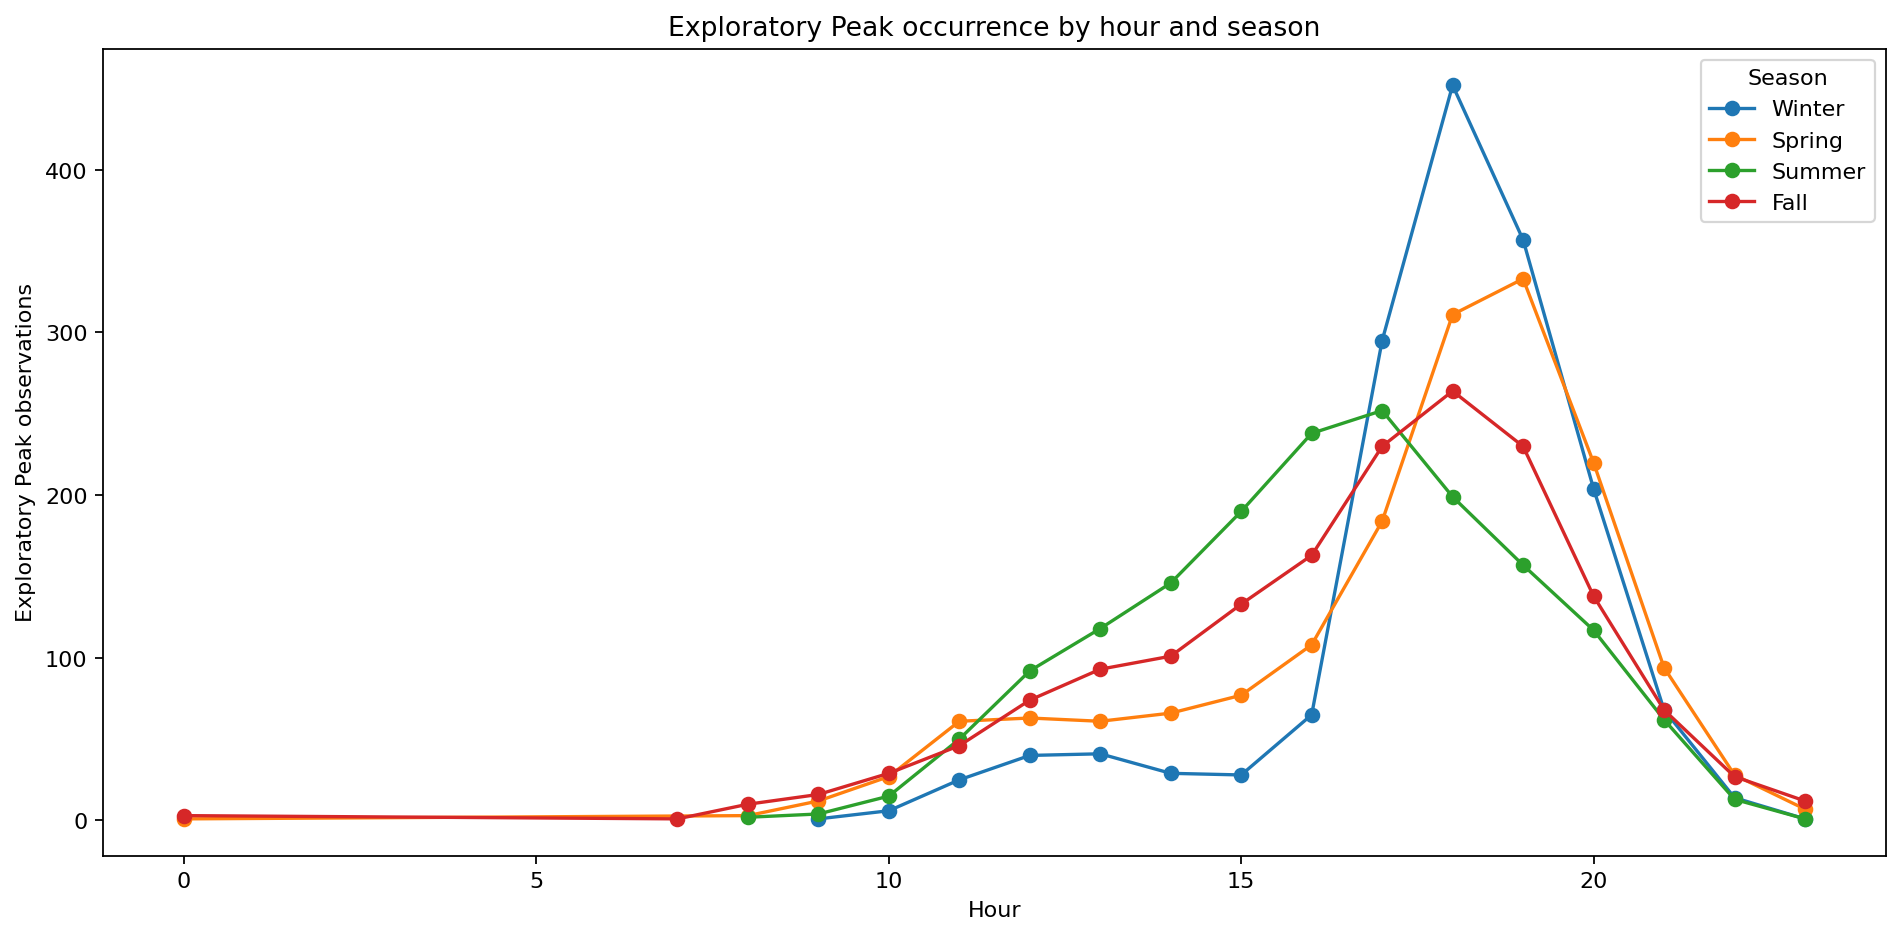


05_05_peaks_by_month.png


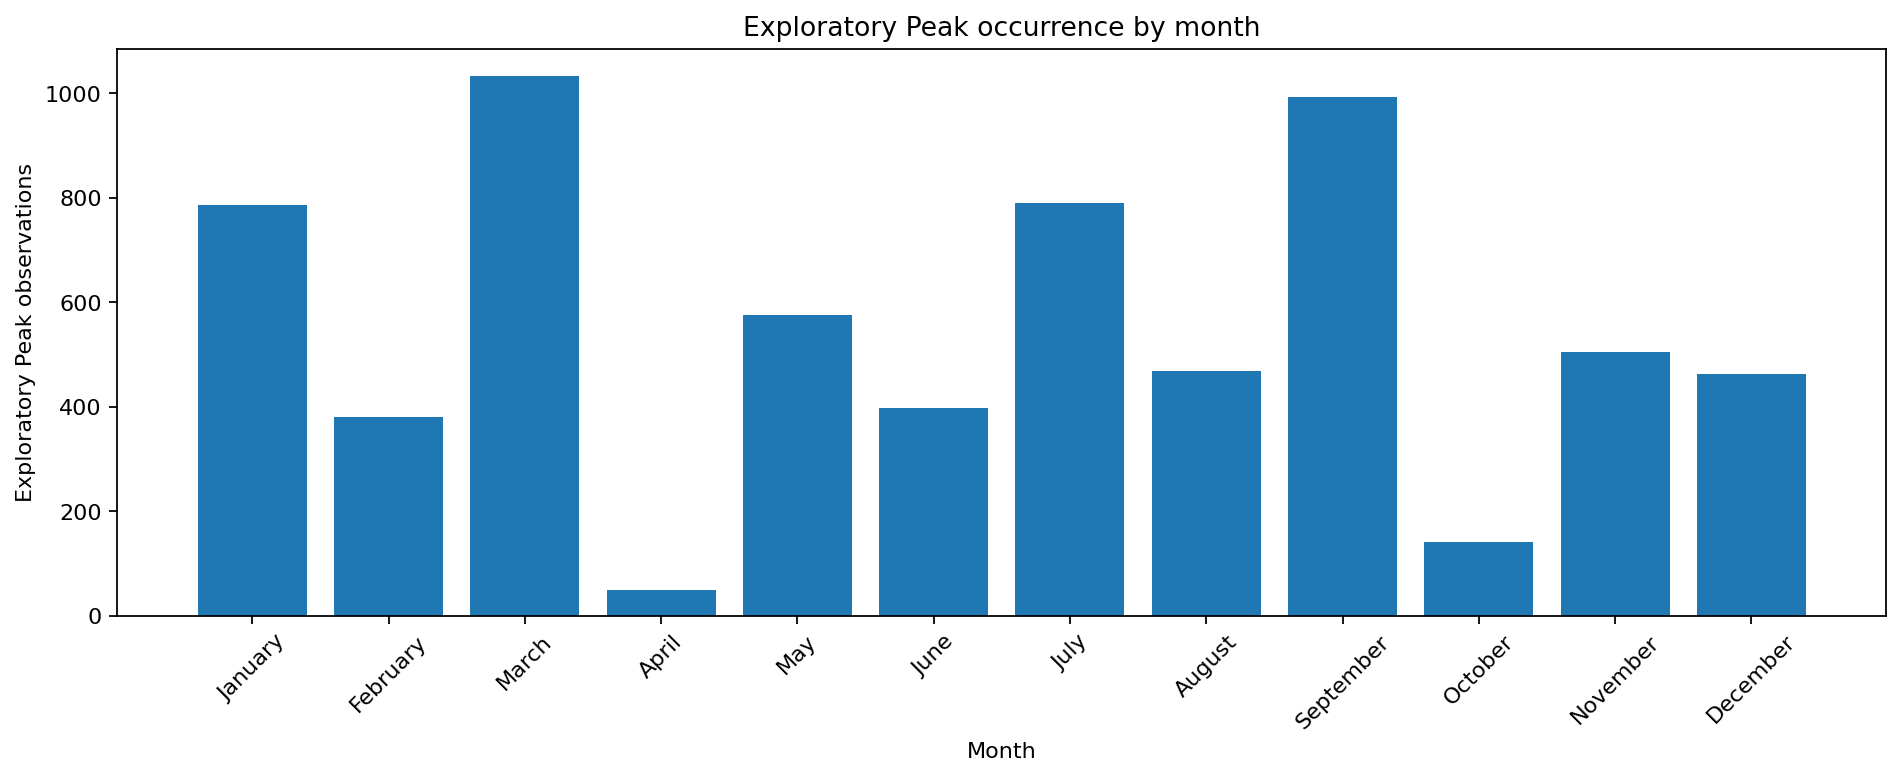


05_05_peaks_by_weekday.png


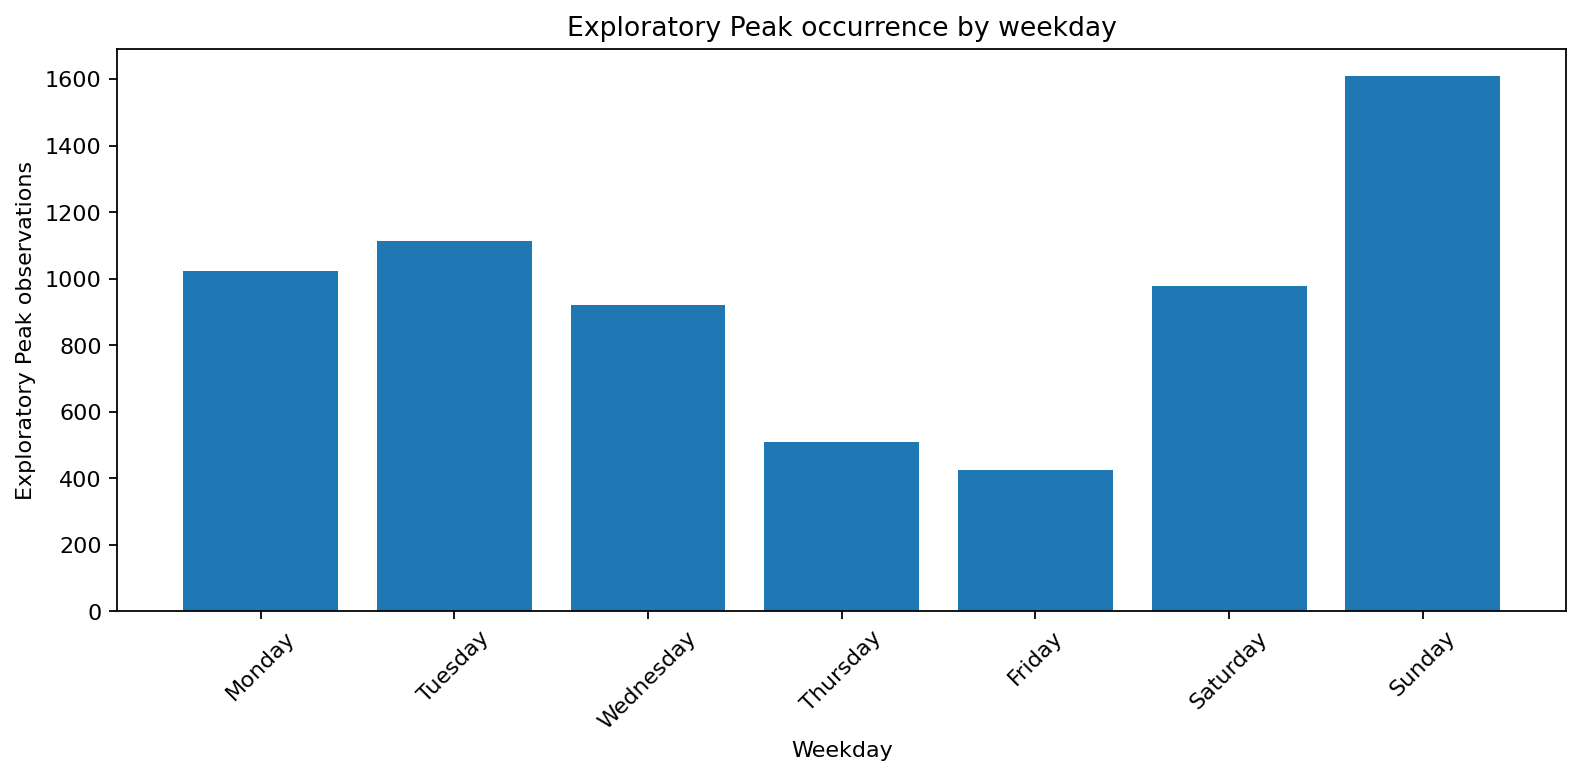


05_05_temperature_extremes_by_fsa.png


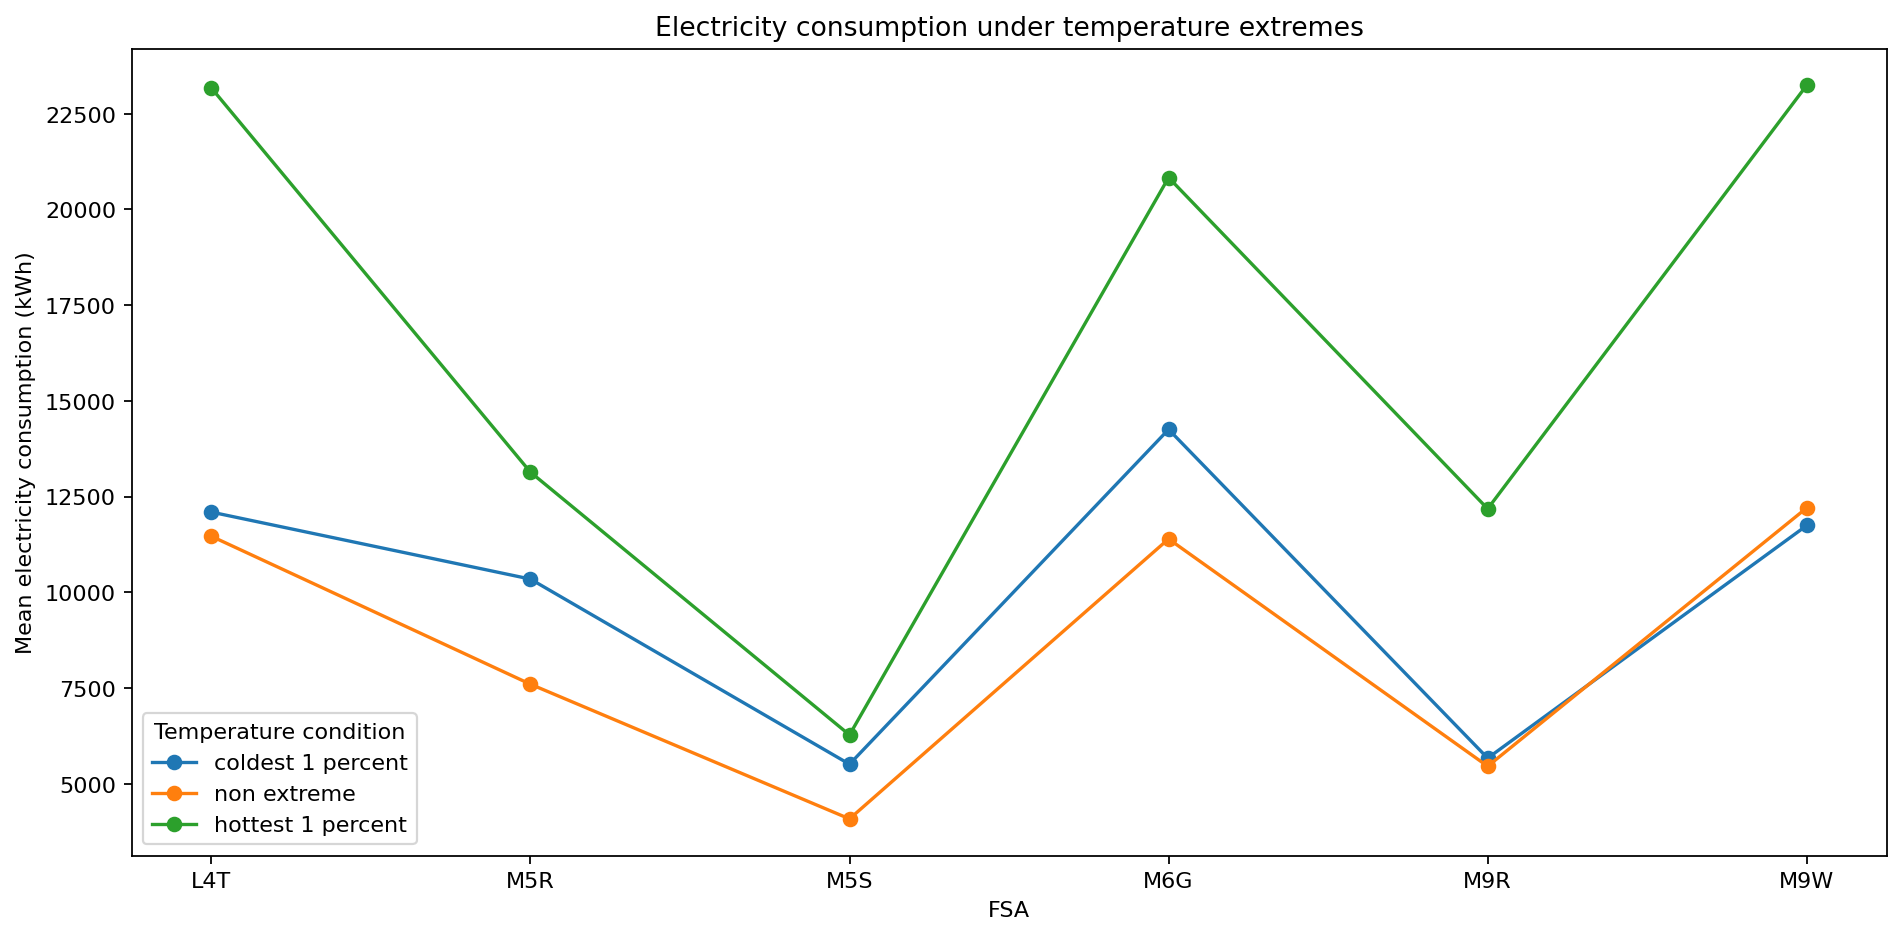

In [30]:
# Display all figures generated by the 05.05 analysis
generated_figures = sorted(
    FIGURES_DIR.glob("05_05_*.png")
)

print(
    f"Generated figures: {len(generated_figures)}"
)

for figure_path in generated_figures:
    print(f"\n{figure_path.name}")
    display(
        Image(
            filename=str(figure_path)
        )
    )